Loaded I and Q arrays:
In-Phase (I): [  0  89  73 ... -94  28 -91]
Quadrature (Q): [  0 -30  59 ...  85  32  87]


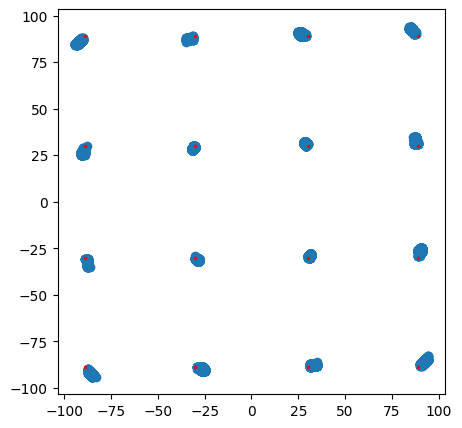

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def read_iq_pairs(filename):
    """
    Reads a text file with lines formatted as: "%d %d"
    Returns:
        in_phase: NumPy array with the first column (I component)
        quadrature: NumPy array with the second column (Q component)
    """
    try:
        data = np.loadtxt(filename, dtype=int)
        in_phase = data[:, 0]
        quadrature = data[:, 1]
        return in_phase, quadrature
    except Exception as e:
        print(f"Error reading file: {e}")
        return None, None

if __name__ == "__main__":
    filepath = "output.txt"  # Change if needed
    in_phase, quadrature = read_iq_pairs(filepath)

    if in_phase is not None and quadrature is not None:
        print("Loaded I and Q arrays:")
        print("In-Phase (I):", in_phase)
        print("Quadrature (Q):", quadrature)
    else:
        print("Failed to load data.")

    qam16_constellation = {
    0: (-3, -3), 1: (-3, -1), 2: (-3, 1), 3: (-3, 3),
    4: (-1, -3), 5: (-1, -1), 6: (-1, 1), 7: (-1, 3),
    8: (1, -3), 9: (1, -1), 10: (1, 1), 11: (1, 3),
    12: (3, -3), 13: (3, -1), 14: (3, 1), 15: (3, 3)    
    }   

    k = np.real( complex(1,0) * np.exp(1j*np.deg2rad(45)) ) / 3.05

    qam16_constellation = {key: (k * I, k * Q) for key, (I, Q) in qam16_constellation.items()}

    qam16_constellation = {key: (round(I*2**7), round(Q*2**7)) for key, (I, Q) in qam16_constellation.items()}    

    symbols=np.array([complex(i,q) for i,q in qam16_constellation.values()])

    plt.figure(figsize=(5,5))
    plt.scatter(in_phase[3000:10000], quadrature[3000:10000])
    plt.scatter(np.real(symbols), np.imag(symbols), s=2, color='red')

